In [1]:
import numpy as np
import matplotlib.pyplot as plt
                                                                             
plt.rcParams.update(
    {
        "text.usetex": True,
        "axes.labelsize": 20,
        "axes.grid": True,
        "legend.fontsize": 13,
        "xtick.labelsize": 15,
        "ytick.labelsize": 15,
        "figure.constrained_layout.use": True
    }
)

In [2]:
# directory = "./output/Veff_N32_eta5e6_init1e2_mZp1e2/"
directory = "./output/mexhat/mu_MPle-2/"
SAVE = True

### Scale factor $a(\tilde\eta)$

The file contains the following columns:

$\tilde\eta$ | $a$ | $a'$ | $\frac{a'}{a}$

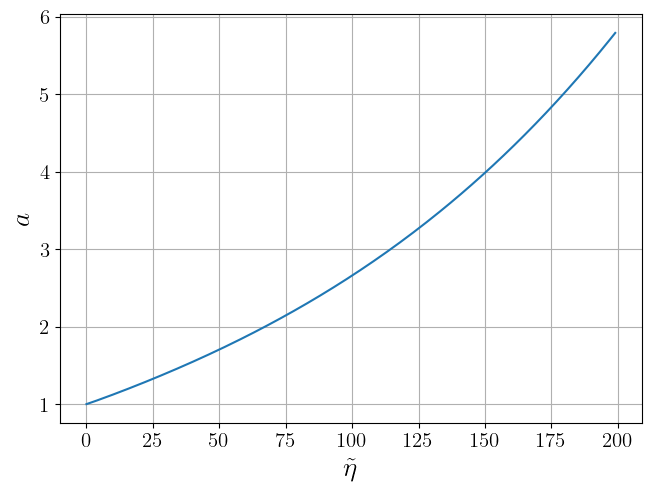

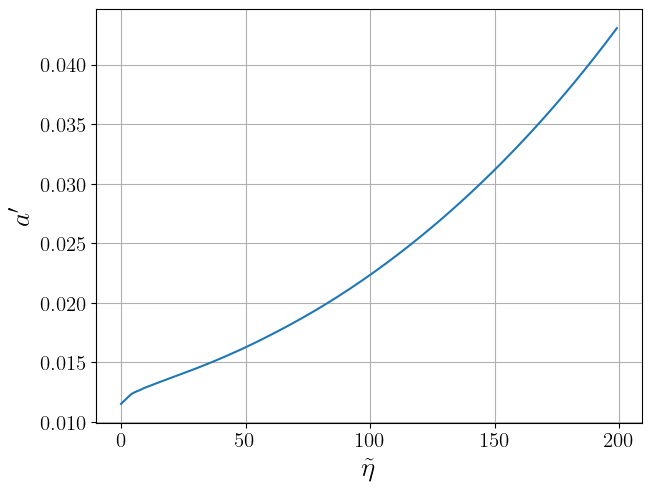

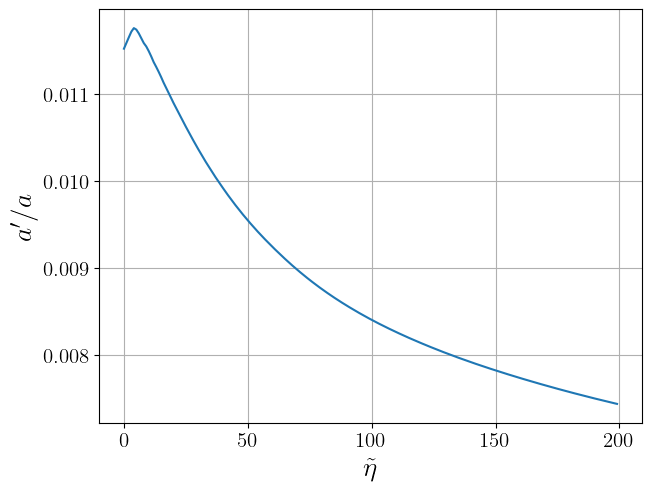

In [3]:
# load the file in aDat
aDat = np.loadtxt(directory + "average_scale_factor.txt")

#plot a
plt.figure(0)
plt.plot(aDat[:,0], aDat[:,1])
plt.ylabel("$a$")
plt.xlabel(r'$\tilde\eta$')


#plot a'
plt.figure(1)
plt.plot(aDat[:,0], aDat[:,2])
plt.ylabel("$a'$")
plt.xlabel(r'$\tilde\eta$')



#plot a'/a
plt.figure(2)
plt.plot(aDat[:,0], aDat[:,3])
plt.ylabel(r"$a'/a$")
plt.xlabel(r"$\tilde\eta$")


plt.show()

### Average Field Values 

The files for the averages of the scalar fields contain the following columns:

$\eta$ | $\langle \tilde\phi_n \rangle$ | $\langle \tilde\phi'_n \rangle$ | $\langle \tilde\phi^2_n \rangle$ | $\langle \tilde\phi^{'2}_n \rangle$ | $\mathrm{rms}(\tilde\phi_n) $ | $\mathrm{rms}(\tilde\phi'_n) $

200


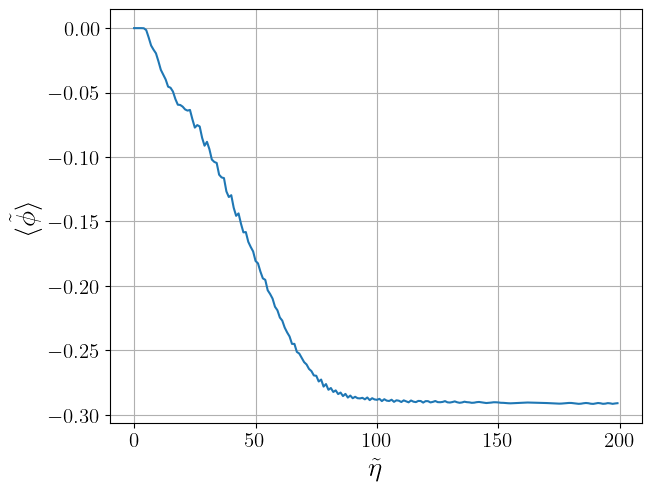

In [4]:
phiDat = np.loadtxt(directory + "average_scalar_0.txt")
                                                                             
eta = phiDat[:, 0]
phi = phiDat[:, 1]
                                                                             
print(len(eta))
lim1 = 0
lim2 = 10000
eta = eta[lim1:lim2]
phi = phi[lim1:lim2]

# ---------------------------
# Plotting average field values
# ---------------------------
                                                                             
plt.figure()
plt.plot(eta, phi)
plt.xlabel(r"$\tilde\eta$")
plt.ylabel(r"$\langle\tilde\phi\rangle$")
#plt.title("N=64, tMax=3e6, dt=0.05, phi_init=500GeV, mZp=1e3, g=0.01, LF")
# plt.savefig(savefile, format="pdf")
plt.show()

### "Energy conservation" (the $1^{st}$ Friedmann's equation is satisfied)
The file  that checks the first Friedmann's equation contains

$\tilde\eta$ | $\frac{\langle LHS - RHS\rangle}{\langle LHS + RHS\rangle}$ | $\langle LHS \rangle$ | $\langle RHS \rangle$ 

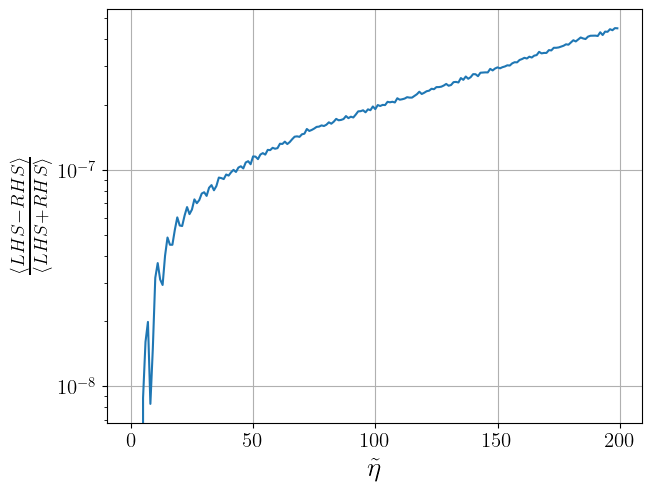

In [5]:
enConsDat = np.loadtxt(directory + "average_energy_conservation.txt")
eta = enConsDat[:,0]
dev = enConsDat[:,1]
plt.figure()
plt.plot(eta, dev)
plt.xlabel(r"$\tilde\eta$")
plt.ylabel(r"$\frac{\langle LHS - RHS\rangle}{\langle LHS + RHS\rangle}$")
# plt.title("N=64, tMax=3e6, dt=0.05, phi_init=500GeV, mZp=1e5, g=0.01, LF")
plt.yscale('log')
plt.show()

### Energy densities

The file with the energy densities contains

$\tilde\eta$ | $\tilde E_K^{(0)}$ | $\tilde E_G^{(0)}$ |$\dots$| $\tilde E_K^{(N_s-1)}$ | $\tilde E_G^{(N_s-1)}$ |  $\tilde E_V^{(0)}$ | $\dots$ |  $\tilde E_V^{(N_p-1)}$ | $\langle \tilde \rho \rangle$

200
mexhat_energies_mu_MPle-2


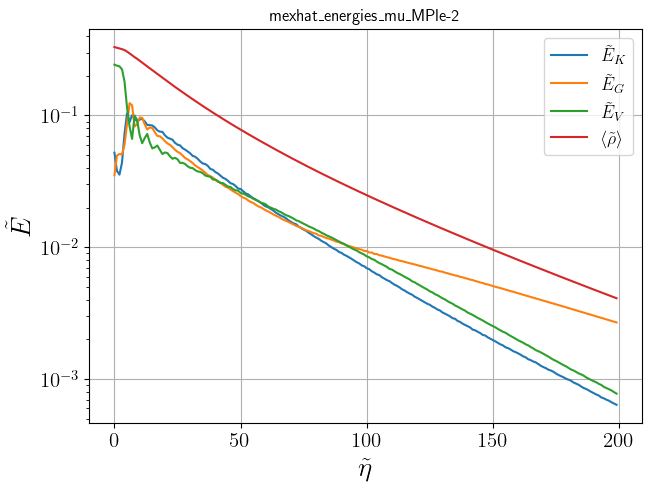

In [6]:
enDat = np.loadtxt(directory + "average_energies.txt")
eta = enDat[:,0]

nColumns = np.shape(enDat)[1]

labels = [r"$\tilde E_K$", r"$\tilde E_G$", r"$\tilde E_V$", r"$\langle \tilde \rho \rangle$"]

print(len(eta))
lim1 = 0
lim2 = len(eta)
eta = eta[lim1:lim2]


plt.figure(0)
for i in range(1,nColumns):
    plt.plot(eta, enDat[lim1:lim2,i], label = labels[i-1])
    #plt.plot(eta, aDat[:,1]**4 * enDat[:,i], label = labels[i-1])
plt.yscale('log')
plt.xlabel(r"$\tilde \eta$")
plt.ylabel(r"$\tilde E$")
plt.legend()
if SAVE:
    savefile = f"mexhat_energies_{directory[-10:-1]}"
    plt.title(savefile)
    print(savefile)
    plt.savefig('./plotting/figures/mexhat/'+savefile+'.pdf', format = 'pdf')
plt.show()

### Spectra

Spectra output varies depending on the option. The default one generates a txt file with the following columns:

$\tilde k$ | $\tilde\Delta_{\tilde\phi}$ | $\tilde\Delta_{\tilde\phi'}$ | $\tilde n_{\tilde\phi}$ | bin multiplicity

In [7]:
def load_spectrum(filename, comment = '#'):
    # The next few lines open the file and count
    # how many bins in one spectrum
    file = open(filename)
    nBins = 0
    # read first line
    line = file.readline()
    # while no blank we continue
    while line != "\n":
        # if not a comment line (header for instance)
        # we count one line
        if(line[0] != comment):
            nBins +=1
        # read next line
        line = file.readline()
    file.close()

    # now we know nBins. We still need to actually read the data.
    fileSp = np.loadtxt(filename, comments=comment)

    # find how many spectra are in the files
    nSpectra = len(fileSp) / nBins

    return fileSp, int(nBins), int(nSpectra)


def plot_spectrum(spectra, column, nBins, nSpectra, colormap = 'plasma'):
    nPlots = 1000 # Number of time steps to plot (otherwise too slow)
    colors = plt.get_cmap(colormap, nPlots)
    for i in range(nSpectra-nPlots, nSpectra):
        plt.plot(spectra[i*nBins:(i+1)*nBins,0], spectra[i*nBins:(i+1)*nBins,column], color=colors(i))
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel(r'$\tilde k$')

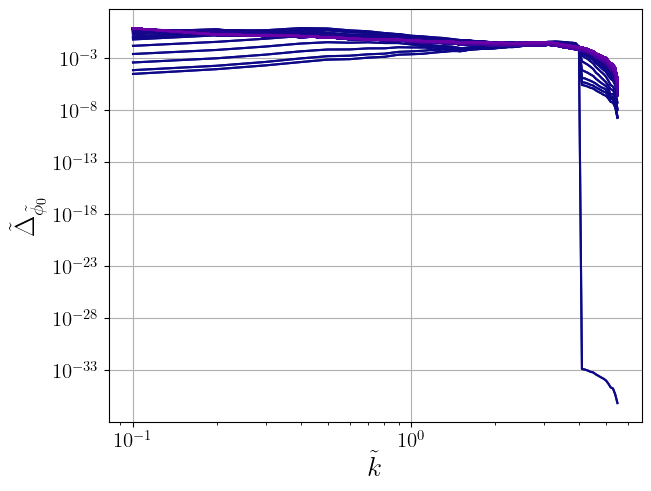

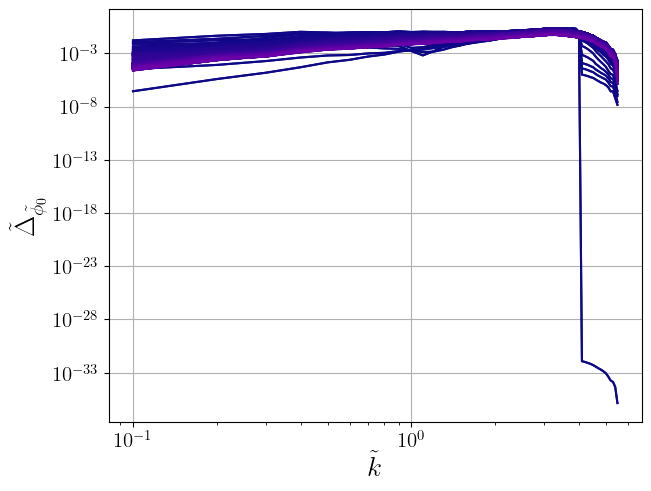

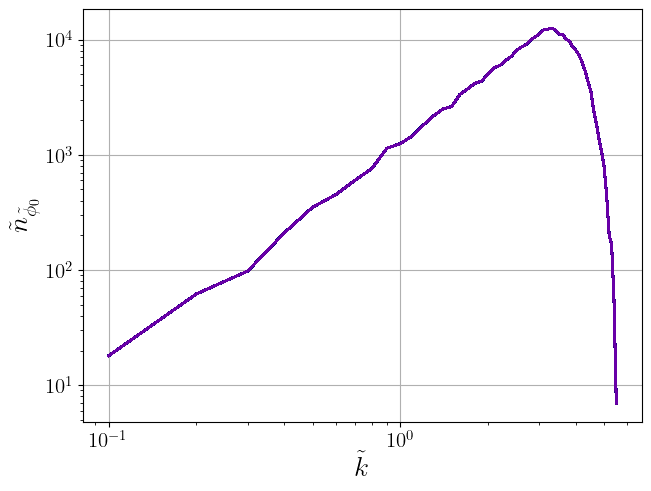

In [8]:
infSp, nBins, nSpectra = load_spectrum(directory + "spectra_scalar_0.txt")

plt.figure(0)
plot_spectrum(infSp, 1,  nBins, nSpectra)
plt.ylabel(r'$\tilde{\Delta}_{\tilde\phi_0}$')
#plt.ylim([1e-19,1e-4])

plt.figure(1)
plot_spectrum(infSp, 2,  nBins, nSpectra)
plt.ylabel(r'$\tilde{\Delta}_{\tilde\phi_0}$')
#plt.ylim([1e-19,1e-4])

plt.figure(2)
plot_spectrum(infSp, 3,  nBins, nSpectra)
plt.ylabel(r'$\tilde {n}_{\tilde\phi_0}$')
#plt.ylim([1e-1,1e13]);

plt.show()

### Gravitational Wave Spectrum

mexhat_GWs_mu_MPle-2


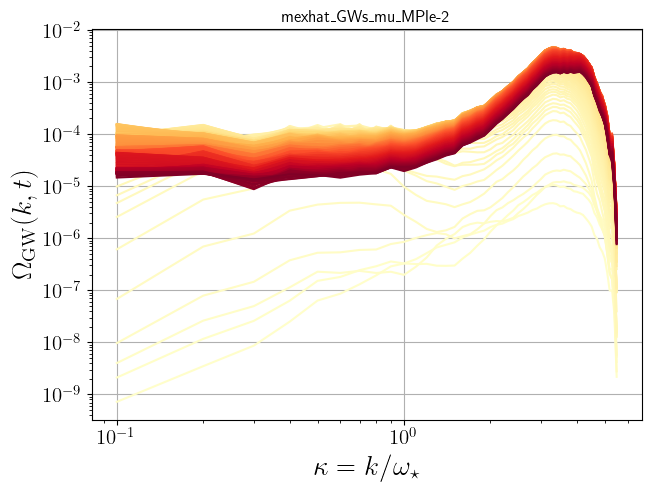

In [9]:
filename = directory + "spectra_gws.txt"

# Load the file, split into blocks separated by blank lines
with open(filename) as f:
    # Read contents and create list of strings of the form:
    # [
    # "κ Ω_GW(k, t) #l\n
    #  κ Ω_GW(k, t) #l\n
    # ...",
    # "κ Ω_GW(k, t) #l\n
    #  κ Ω_GW(k, t) #l\n
    # ...",
    # ...
    # ]
    content = f.read().strip().split("\n\n")
    content = content[-10000:] # Only plot the last 10000 time steps to save time
cmap = plt.get_cmap("YlOrRd", len(content))

plt.figure()                                                           
for j, block in enumerate(content):
    # Use np.loadtxt on each block
    data = np.loadtxt(block.splitlines())
    kappa = data[:, 0]
    omega_gw = data[:, 1]
    plt.plot(kappa, omega_gw, color=cmap(j), label=f"Time step {j+1}")
                                                                       
# plt.ylim(10e-41, 10e-33)
# plt.xlim(0.2, 13)
plt.xlabel(r"$\kappa=k/\omega_\star$")
plt.ylabel(r"$\Omega_\mathrm{GW}(k,t)$")
plt.yscale("log")
plt.xscale("log")
if SAVE:
    savefile = f"mexhat_GWs_{directory[-10:-1]}"
    plt.title(savefile)
    print(savefile)
    plt.savefig('./plotting/figures/mexhat/'+savefile+'.pdf', format = 'pdf')